# Car Price Prediction (User Dataset)
This notebook uses your dataset `car_data.csv` and trains models to predict `Selling_Price`.

Steps:
1. Load data
2. Feature engineering (Age)
3. Preprocessing (scaling, one-hot)
4. Train RandomForest and GradientBoosting
5. Evaluate and save the best model


In [15]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load dataset (must be in the same folder)
df = pd.read_csv('car_data.csv')
df.head()


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Quick EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       

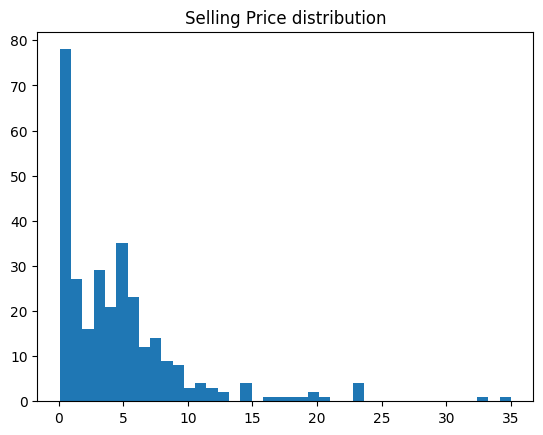

In [16]:
print(df.info())
print(df.describe())
plt.hist(df['Selling_Price'], bins=40)
plt.title('Selling Price distribution')
plt.show()


## Feature engineering & preprocessing

In [18]:
# --- Preprocessing & pipeline setup (compatibility-safe) ---
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_features = ['Present_Price','Driven_kms','Age']
numeric_transformer = Pipeline([('scaler', StandardScaler())])

categorical_features = ['Fuel_Type','Transmission','Owner','Car_Name']

# Try the modern argument name, then fall back to older ones.
try:
    categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    try:
        categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse=False)
    except TypeError:
        # Last resort: create OneHotEncoder with default args (will output sparse matrix)
        categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
], remainder='drop')

print("Preprocessor created. sklearn version info:")
import sklearn
print("scikit-learn:", sklearn.__version__)


Preprocessor created. sklearn version info:
scikit-learn: 1.7.2


## Train models and evaluate

In [19]:
# --- Train models (robust metrics & compatibility) ---
import joblib
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Prepare X,y (ensure these are defined earlier)
# X = df[features]; y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'rf': RandomForestRegressor(n_estimators=200, random_state=42),
    'gbr': GradientBoostingRegressor(n_estimators=200, random_state=42)
}

results = {}
pipelines = {}
for name, est in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('regressor', est)])
    print(f'Training {name}...')
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)   # compatible
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_test, preds)

    results[name] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    pipelines[name] = pipe
    print(f'{name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}')

best_name = max(results.keys(), key=lambda k: results[k]['r2'])
best_pipeline = pipelines[best_name]
print('Best model:', best_name)
joblib.dump(best_pipeline, 'car_price_model_user.joblib')


Training rf...
rf: MAE=0.6117, RMSE=0.9337, R2=0.9622
Training gbr...
gbr: MAE=0.5558, RMSE=0.9333, R2=0.9622
Best model: gbr


['car_price_model_user.joblib']

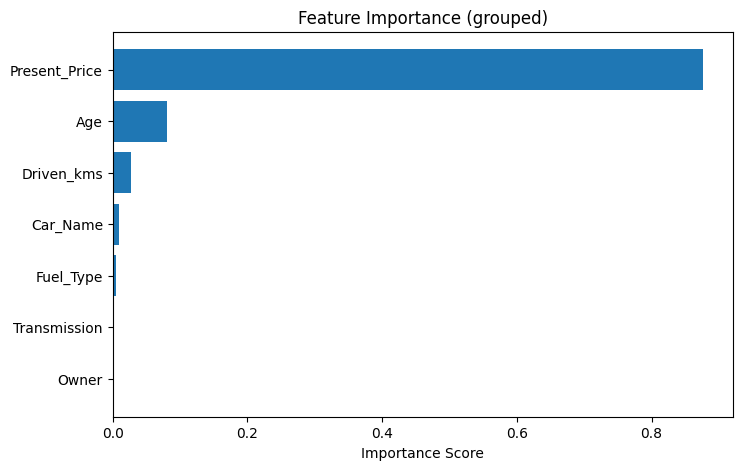

In [21]:
# --- Clean Feature Importance Plot (grouped by original features) ---
import numpy as np
import matplotlib.pyplot as plt
import joblib

# load the trained model if needed
try:
    best_pipeline
except NameError:
    best_pipeline = joblib.load("car_price_model_user.joblib")

pre = best_pipeline.named_steps['preprocessor']
reg = best_pipeline.named_steps['regressor']

# feature groups
numeric_features = ['Present_Price', 'Driven_kms', 'Age']
categorical_features = ['Fuel_Type','Transmission','Owner','Car_Name']

# get one-hot encoder
cat = pre.named_transformers_['cat']

# get OHE feature names
try:
    ohe_names = cat.get_feature_names_out(categorical_features)
except:
    ohe_names = cat.get_feature_names(categorical_features)

# combine all feature names after preprocessing
all_feature_names = numeric_features + list(ohe_names)

# raw importances from model
importances = reg.feature_importances_

# ----- GROUP IMPORTANCES -----
group_importance = {
    'Present_Price': 0,
    'Driven_kms': 0,
    'Age': 0,
    'Fuel_Type': 0,
    'Transmission': 0,
    'Owner': 0,
    'Car_Name': 0
}

for feat, imp in zip(all_feature_names, importances):
    if feat in numeric_features:
        group_importance[feat] += imp
    else:
        # check which categorical group the feature belongs to
        for group in categorical_features:
            if feat.startswith(group):
                group_importance[group] += imp
                break

# sort by importance
sorted_groups = sorted(group_importance.items(), key=lambda x: x[1], reverse=True)

# ----- PLOT -----
plt.figure(figsize=(8,5))
plt.barh([g[0] for g in sorted_groups], [g[1] for g in sorted_groups])
plt.gca().invert_yaxis()
plt.title("Feature Importance (grouped)")
plt.xlabel("Importance Score")
plt.show()


## Example: predict a single car

In [ ]:
example = X_test.iloc[[0]].copy()
print('Example features:')
print(example)
print('Predicted price:', best_pipeline.predict(example)[0])
print('Actual price:', y_test.iloc[0])


## Next steps / improvements
- Hyperparameter tuning (GridSearchCV / RandomizedSearch / Optuna)
- Try XGBoost / LightGBM
- SHAP for model explanations
- More features (km_per_year, brand grouping, etc.)


In [ ]:
# The dataset itself has almost no rows with Owners > 0
#When a category appears rarely, the OneHotEncoder 
# & model give it very low weight, so it has no effect.

import pandas as pd
df = pd.read_csv('car_data.csv')
df['Owner'].value_counts()

# KAGGLE DATA SET PROBLEM : Owner and other categorical features have very low influence because the dataset contains weak relationships.

Owner
0    290
1     10
3      1
Name: count, dtype: int64